In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
base_path = os.path.join("..", "data", "data_hm")
files_lst = os.listdir(base_path)
print(f"Users in dataset: {files_lst}")

Users in dataset: ['.DS_Store', '007', '000', '009', '008', '001', '006', '010', '003', '004', '005', '002']


In [4]:
len(files_lst)

12

In [5]:
users = sorted(u for u in os.listdir(base_path) if u.isdigit())[:50]

all_data = []
for user in users:
    traj_path = os.path.join(base_path, user, "Trajectory")
    if not os.path.exists(traj_path):
        continue
    for file in os.listdir(traj_path):
        if file.endswith(".plt"):
            d = pd.read_csv(
                os.path.join(traj_path, file),
                skiprows=6, header=None,
                names=["lat", "lon", "unused", "altitude", "days", "date", "time"],
            )
            d["datetime"] = pd.to_datetime(d["date"] + " " + d["time"])
            d["user"] = user
            all_data.append(d)

full_df = pd.concat(all_data, ignore_index=True)
print(full_df.shape)

(2781512, 9)


In [6]:
full_df[full_df["user"] == "001"]

,lat,lon,unused,altitude,days,date,time,datetime,user
173870,40.013794,116.306530,0,139,39796.997141,2008-12-14,23:55:53,2008-12-14 23:55:53,001
173871,40.013833,116.306538,0,144,39796.997199,2008-12-14,23:55:58,2008-12-14 23:55:58,001
173872,40.013967,116.306339,0,101,39797.001053,2008-12-15,00:01:31,2008-12-15 00:01:31,001
173873,40.014051,116.306288,0,102,39797.001100,2008-12-15,00:01:35,2008-12-15 00:01:35,001
173874,40.014113,116.306160,0,113,39797.001157,2008-12-15,00:01:40,2008-12-15 00:01:40,001
...,...,...,...,...,...,...,...,...,...
282472,40.013804,116.306532,0,90,39744.502928,2008-10-23,12:04:13,2008-10-23 12:04:13,001
282473,40.013803,116.306532,0,90,39744.502986,2008-10-23,12:04:18,2008-10-23 12:04:18,001
282474,40.013803,116.306532,0,90,39744.503044,2008-10-23,12:04:23,2008-10-23 12:04:23,001
282475,40.013803,116.306532,0,90,39744.503079,2008-10-23,12:04:26,2008-10-23 12:04:26,001


In [7]:

def haversine_m(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * 6_371_000 * np.arcsin(np.sqrt(a))

def detect_stay_points(traj, dist_m=200, time_s=20*60):
    lat, lon = traj["lat"].to_numpy(), traj["lon"].to_numpy()
    t = traj["datetime"].to_numpy()
    n, sp, i = len(traj), [], 0
    while i < n - 1:
        j = i + 1
        while j < n and haversine_m(lat[i], lon[i], lat[j], lon[j]) <= dist_m:
            j += 1
        if (t[j-1] - t[i]) / np.timedelta64(1, "s") >= time_s:
            sp.append({"lat": lat[i:j].mean(), "lon": lon[i:j].mean()})
            i = j
        else:
            i += 1
    return pd.DataFrame(sp)

# ex1

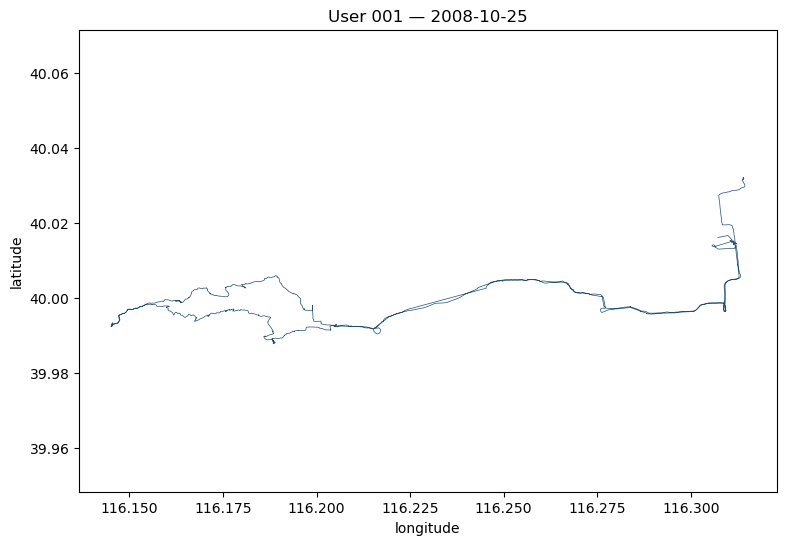

In [8]:
u = full_df[full_df["user"] == "001"].copy()
u["day"] = u["datetime"].dt.date

day = u["day"].value_counts().idxmax()      # busiest day for user 001
d = u[u["day"] == day].sort_values("datetime")

plt.figure(figsize=(9, 6))
plt.plot(d["lon"], d["lat"], lw=0.5, color="#1f4e79")
plt.title(f"User 001 — {day}")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.axis("equal")
plt.show()

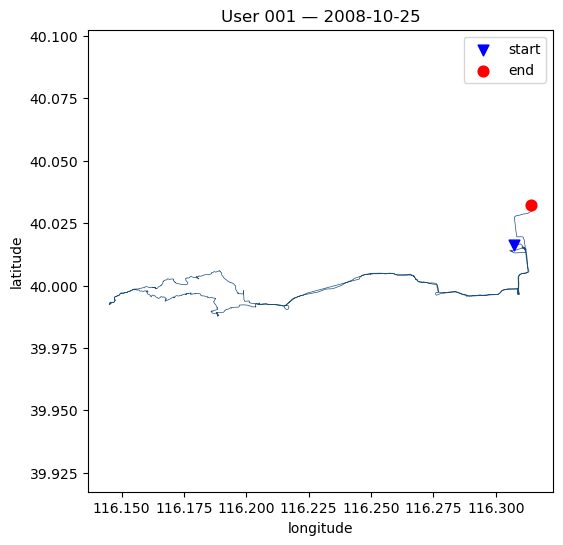

In [9]:
plt.figure(figsize=(6, 6))
plt.plot(d["lon"], d["lat"], lw=0.5, color="#1f4e79")
plt.scatter(d["lon"].iloc[0],  d["lat"].iloc[0],  c="blue", marker="v", s=60, label="start", zorder=3)
plt.scatter(d["lon"].iloc[-1], d["lat"].iloc[-1], c="red",   s=60, label="end",   zorder=3)
plt.title(f"User 001 — {day}")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.axis("equal"); plt.legend()
plt.show()

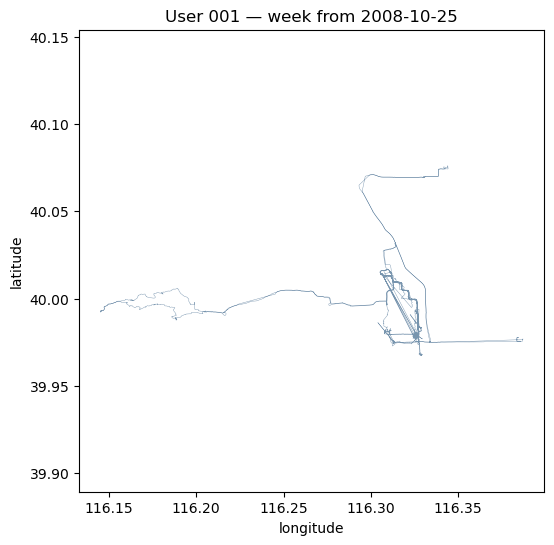

In [10]:
week = u[(u["day"] >= day) & (u["day"] < day + pd.Timedelta(days=7))]

plt.figure(figsize=(6, 6))
plt.plot(week["lon"], week["lat"], lw=0.3, alpha=0.6, color="#1f4e79")
plt.title(f"User 001 — week from {day}")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.axis("equal")
plt.show()

# ex2

In [11]:
sp = detect_stay_points(d)          # d = user 001's one day, from step 1
print(f"raw points: {len(d)}  →  stay points: {len(sp)}")

raw points: 7319  →  stay points: 9


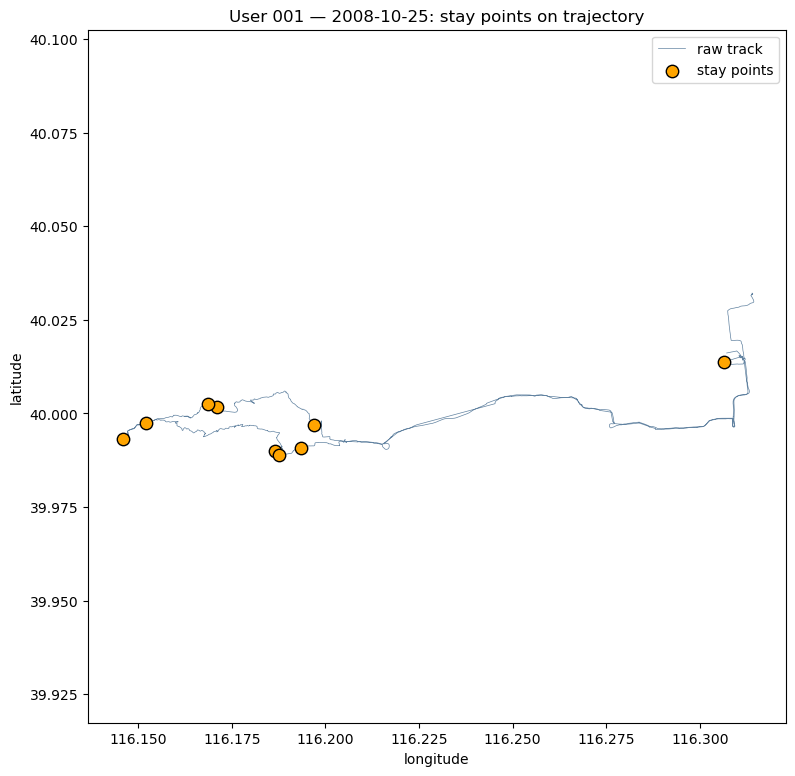

In [12]:
plt.figure(figsize=(9, 9))
plt.plot(d["lon"], d["lat"], lw=0.5, color="#1f4e79", alpha=0.7, label="raw track")
plt.scatter(sp["lon"], sp["lat"], c="orange", s=80, edgecolor="k", zorder=3, label="stay points")
plt.title(f"User 001 — {day}: stay points on trajectory")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.axis("equal"); plt.legend()
plt.show()

In [13]:
for thr in [5, 20, 60]:
    n_sp = len(detect_stay_points(d, time_s=thr*60))
    print(f"T_threh = {thr:>2} min  →  {n_sp} stay points")

T_threh =  5 min  →  44 stay points
T_threh = 20 min  →  9 stay points
T_threh = 60 min  →  1 stay points


T_threh =  5 min  →  44 stay points
T_threh = 20 min  →  9 stay points
T_threh = 60 min  →  1 stay points


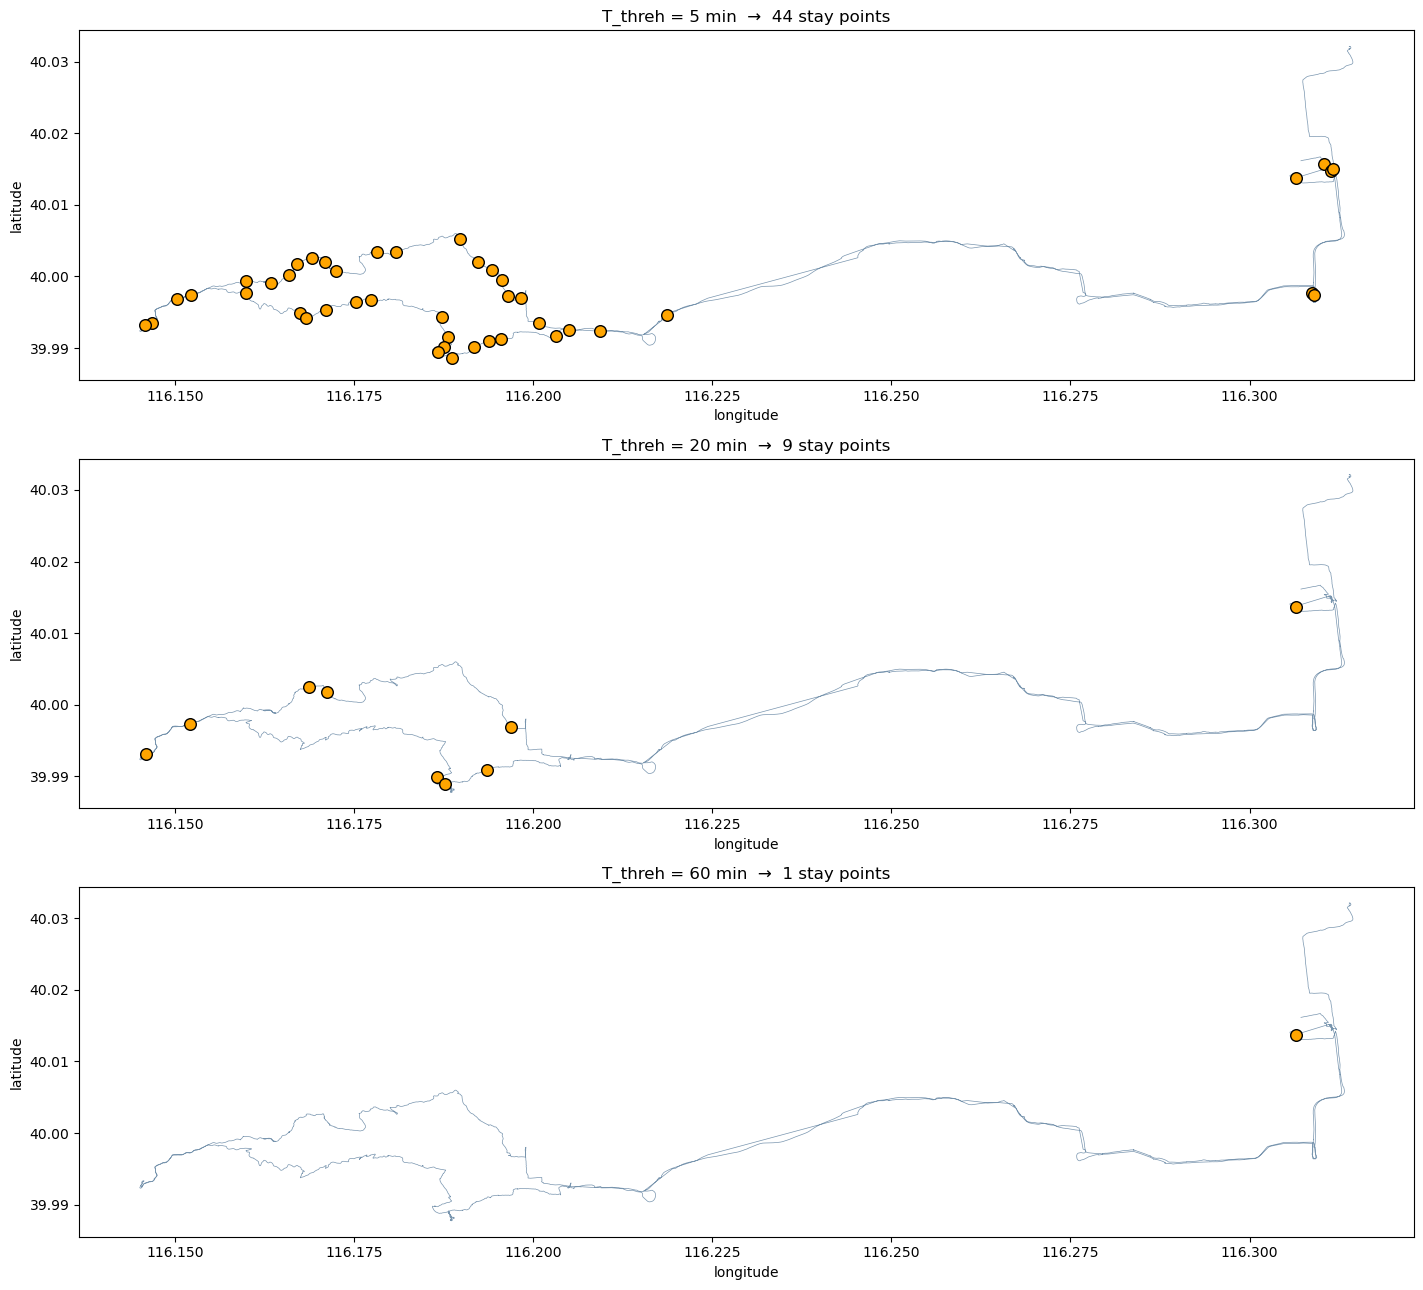

In [14]:
thresholds = [5, 20, 60]

fig, axes = plt.subplots(3, 1, figsize=(20, 13))
for ax, thr in zip(axes, thresholds):
    sp_thr = detect_stay_points(d, time_s=thr*60)
    print(f"T_threh = {thr:>2} min  →  {len(sp_thr)} stay points")
    ax.plot(d["lon"], d["lat"], lw=0.5, color="#1f4e79", alpha=0.6)
    if len(sp_thr):
        ax.scatter(sp_thr["lon"], sp_thr["lat"], c="orange", s=70, edgecolor="k", zorder=3)
    ax.set_title(f"T_threh = {thr} min  →  {len(sp_thr)} stay points")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# ex3

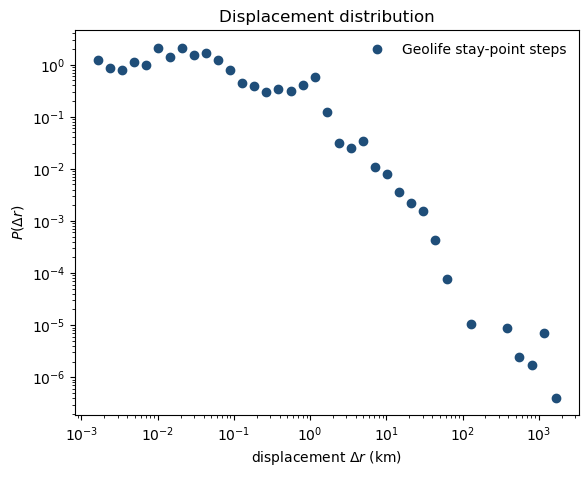

In [15]:
users = [u for u in full_df["user"].unique() if u.isdigit()][:10] 

drs = []
for uid in users:
    g = full_df[full_df["user"] == uid].sort_values("datetime")
    sp = detect_stay_points(g)
    if len(sp) < 2:
        continue
    lat, lon = sp["lat"].to_numpy(), sp["lon"].to_numpy()
    drs.append(haversine_m(lat[:-1], lon[:-1], lat[1:], lon[1:]))

dr_km = np.concatenate(drs) / 1000
dr_km = dr_km[dr_km > 0]

bins = np.logspace(np.log10(dr_km.min()), np.log10(dr_km.max()), 40)
counts, edges = np.histogram(dr_km, bins=bins, density=True)
centers = np.sqrt(edges[:-1] * edges[1:])
m = counts > 0

plt.figure(figsize=(6.5, 5))
plt.loglog(centers[m], counts[m], "o", color="#1f4e79", label="Geolife stay-point steps")
plt.xlabel(r"displacement $\Delta r$ (km)"); plt.ylabel(r"$P(\Delta r)$")
plt.title("Displacement distribution")
plt.legend(frameon=False)
plt.show()

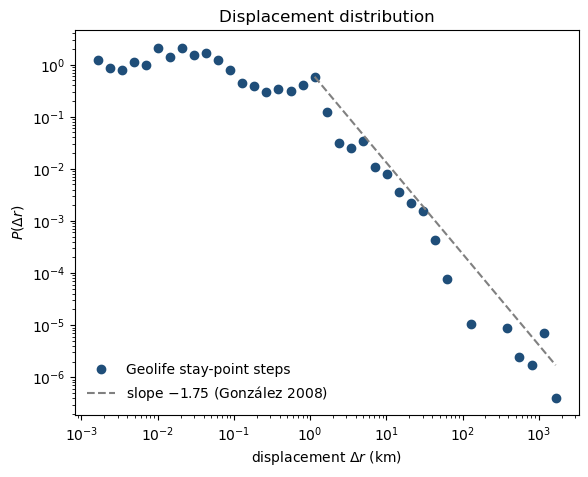

In [16]:
plt.figure(figsize=(6.5, 5))
plt.loglog(centers[m], counts[m], "o", color="#1f4e79", label="Geolife stay-point steps")

tail = centers[m] > 1.0                          # anchor in the power-law tail
gx = centers[m][tail]
gy = gx**(-1.75); gy *= counts[m][tail][0] / gy[0]
plt.loglog(gx, gy, "--", color="grey", label=r"slope $-1.75$ (González 2008)")

plt.xlabel(r"displacement $\Delta r$ (km)"); plt.ylabel(r"$P(\Delta r)$")
plt.title("Displacement distribution")
plt.legend(frameon=False)
plt.show()

# ex4

In [17]:
base_path, os.path.exists(os.path.join(base_path, "010", "labels.txt"))   # should be True

('../data/data_hm', True)

In [19]:
MODE_MAP = {"walk":"walk","bike":"bike","bus":"bus","car":"drive","taxi":"drive",
            "subway":"train","train":"train","run":"walk","motorcycle":"drive",
            "boat":"other","airplane":"other"}
COLORS = {"walk":"#639922","bike":"#1D9E75","bus":"#BA7517",
          "drive":"#185FA5","train":"#993556","other":"#888780"}

u = full_df[full_df["user"] == "010"].sort_values("datetime").reset_index(drop=True)
u["dt"] = u["datetime"].dt.tz_localize("UTC")   
lab = pd.read_csv(os.path.join(base_path, "010", "labels.txt"), sep="\t")
lab.columns = ["start", "end", "mode"]
lab["start"] = pd.to_datetime(lab["start"], utc=True)
lab["end"]   = pd.to_datetime(lab["end"],   utc=True)
lab["mode"]  = lab["mode"].str.strip().str.lower().map(MODE_MAP).fillna("other")

u["mode"] = pd.NA
for _, r in lab.iterrows():
    u.loc[(u["dt"] >= r["start"]) & (u["dt"] <= r["end"]), "mode"] = r["mode"]

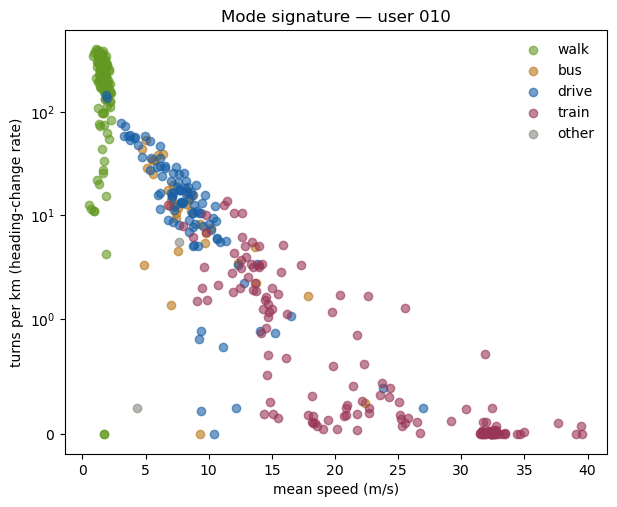

In [20]:
rows = []
for _, r in lab.iterrows():
    seg = u[(u["dt"] >= r["start"]) & (u["dt"] <= r["end"])]
    if len(seg) < 3:
        continue
    lat, lon = seg["lat"].to_numpy(), seg["lon"].to_numpy()
    t = seg["dt"].to_numpy()
    d  = haversine_m(lat[:-1], lon[:-1], lat[1:], lon[1:])
    dt = np.diff(t) / np.timedelta64(1, "s"); dt[dt == 0] = np.nan
    dist_km = np.nansum(d) / 1000
    if dist_km <= 0:
        continue
    head = np.degrees(np.arctan2(np.diff(lon), np.diff(lat)))
    dh = np.abs(np.diff(head)); dh = np.minimum(dh, 360 - dh)
    rows.append({"mode": r["mode"],
                 "speed": np.nanmean(d / dt),
                 "hcr": np.sum(dh > 19) / dist_km})
trips = pd.DataFrame(rows)

plt.figure(figsize=(7, 5.5))
for mode, c in COLORS.items():
    s = trips[(trips["mode"] == mode) & (trips["speed"] <= 40) & (trips["hcr"] <= 400)]
    if len(s):
        plt.scatter(s["speed"], s["hcr"], c=c, alpha=0.6, label=mode)
plt.yscale("symlog", linthresh=1)
plt.xlabel("mean speed (m/s)"); plt.ylabel("turns per km (heading-change rate)")
plt.title("Mode signature — user 010"); plt.legend(frameon=False)
plt.show()

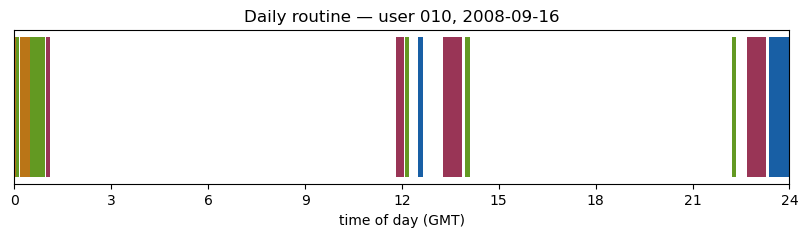

mode
walk     152
train    146
drive     97
bus       34
other      2
Name: count, dtype: int64


In [21]:
day = pd.Timestamp("2008-09-16").date()
dd = u[(u["dt"].dt.date == day) & u["mode"].notna()].sort_values("dt").copy()
dd["hour"] = (dd["dt"] - dd["dt"].dt.normalize()).dt.total_seconds() / 3600
dd["blk"]  = (dd["mode"] != dd["mode"].shift()).cumsum()
runs = dd.groupby("blk").agg(mode=("mode", "first"), h0=("hour", "min"), h1=("hour", "max"))
runs = runs[(runs["h1"] - runs["h0"]) <= 2]       # drop stationary artifact

plt.figure(figsize=(10, 2))
for _, r in runs.iterrows():
    plt.barh(0, max(r["h1"] - r["h0"], 0.1), left=r["h0"], height=0.5,
             color=COLORS.get(r["mode"], "#888780"))
plt.xlim(0, 24); plt.yticks([]); plt.xticks(range(0, 25, 3))
plt.xlabel("time of day (GMT)"); plt.title(f"Daily routine — user 010, {day}")
plt.show()

print(trips["mode"].value_counts())   # most frequent by trip count